# 📈 Stock Market Prediction — 
**Dataset:** DJIA (Dow Jones) | **Model:** LSTM Neural Network

### Steps:
1. Load Data
2. Explore Data (EDA)
3. Prepare Data
4. Build & Train Model
5. Predict & Evaluate

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Libraries loaded!")

Libraries loaded!


## Step 2 — Load Dataset

In [2]:
# Load DJIA stock data from URL
url = "https://raw.githubusercontent.com/llSourcell/Stock_Market_Prediction/master/Data/DJIA%20indices%20data.csv"

df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
df = df.sort_index()          # oldest date first
df = df.fillna(method='ffill') # fill missing values

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (2519, 6)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']


C:\Users\Tanishka Mishra\AppData\Local\Temp\ipykernel_26992\1483963638.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill') # fill missing values


,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2006-12-29,12500.480469,12526.030273,12451.129883,12463.150391,161560000,12463.150391
2007-01-03,12459.540039,12580.349609,12404.820312,12474.519531,327200000,12474.519531
2007-01-04,12473.160156,12510.410156,12403.860352,12480.690430,259060000,12480.690430
2007-01-05,12480.049805,12480.129883,12365.410156,12398.009766,235220000,12398.009766
2007-01-08,12392.009766,12445.919922,12337.370117,12423.490234,223500000,12423.490234


## Step 3 — Explore Data (EDA)

In [3]:
# Basic stats
df.describe().round(2)

,Open,High,Low,Close,Volume,Adj Close
count,2519.00,2519.00,2519.00,2519.00,2.519000e+03,2519.00
mean,13616.03,13697.50,13530.56,13619.38,1.753549e+08,13619.38
std,3043.01,3035.60,3051.76,3044.49,9.652075e+07,3044.49
min,6547.01,6709.61,6469.95,6547.05,8.410000e+06,6547.05
25%,11410.52,11484.92,11317.04,11411.60,1.025800e+08,11411.60
50%,13092.28,13162.64,13022.34,13096.17,1.492500e+08,13096.17
75%,16458.66,16528.95,16377.85,16459.16,2.222200e+08,16459.16
max,19968.97,19987.63,19941.96,19974.62,6.749200e+08,19974.62


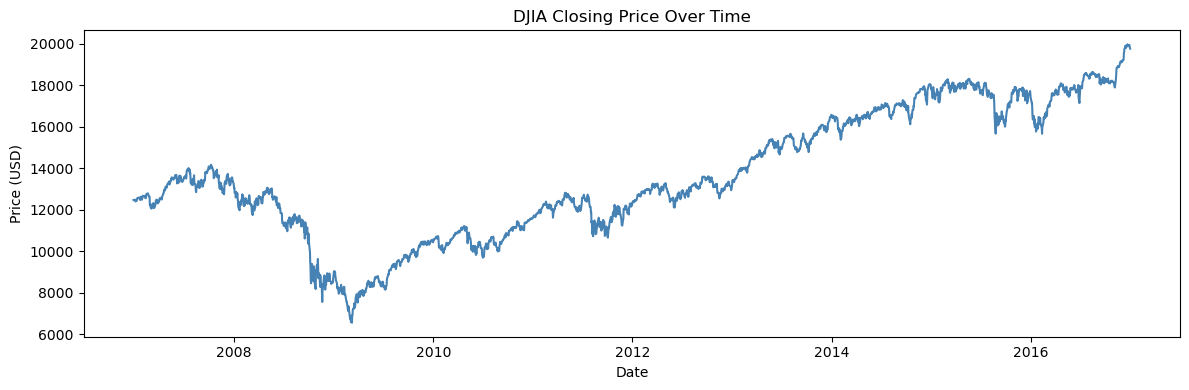

In [4]:
# Plot closing price
plt.figure(figsize=(12, 4))
plt.plot(df['Close'], color='steelblue')
plt.title('DJIA Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

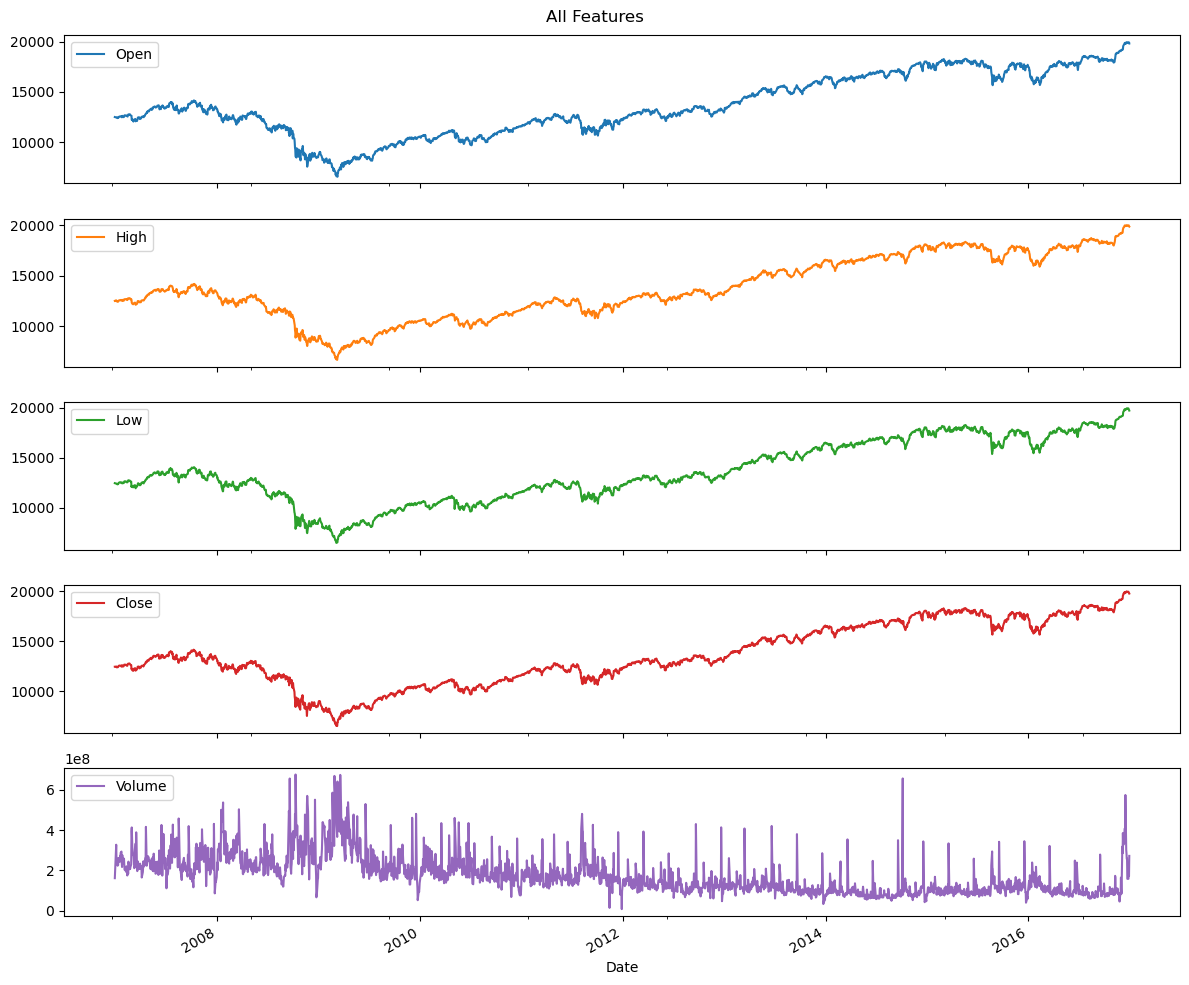

In [5]:
# Plot all columns
df[['Open', 'High', 'Low', 'Close', 'Volume']].plot(subplots=True, figsize=(12, 10), title='All Features')
plt.tight_layout()
plt.show()

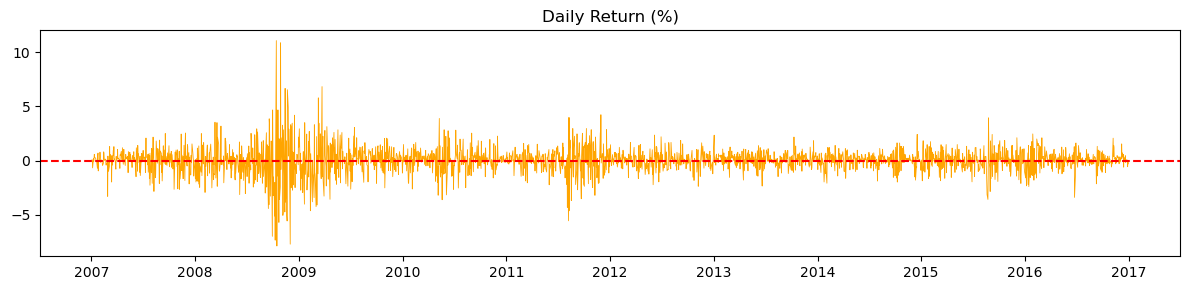

Average Daily Return: 0.0256 %


In [6]:
# Daily return
df['Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(12, 3))
plt.plot(df['Return'], color='orange', linewidth=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Daily Return (%)')
plt.tight_layout()
plt.show()

print("Average Daily Return:", round(df['Return'].mean(), 4), "%")

## Step 4 — Prepare Data for LSTM

In [7]:
# Use only Close price
close = df[['Close']].values

# Scale data between 0 and 1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(close)

# Create sequences (X = past 60 days, y = next day)
def make_sequences(data, steps=60):
    X, y = [], []
    for i in range(steps, len(data)):
        X.append(data[i-steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

STEPS = 60

# Train/Test split (80/20)
split = int(len(scaled) * 0.8)
train = scaled[:split]
test  = scaled[split - STEPS:]   # include lookback buffer

X_train, y_train = make_sequences(train, STEPS)
X_test,  y_test  = make_sequences(test,  STEPS)

# Reshape for LSTM: (samples, timesteps, features)
X_train = X_train.reshape(-1, STEPS, 1)
X_test  = X_test.reshape(-1,  STEPS, 1)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (1955, 60, 1)
X_test  shape: (504, 60, 1)


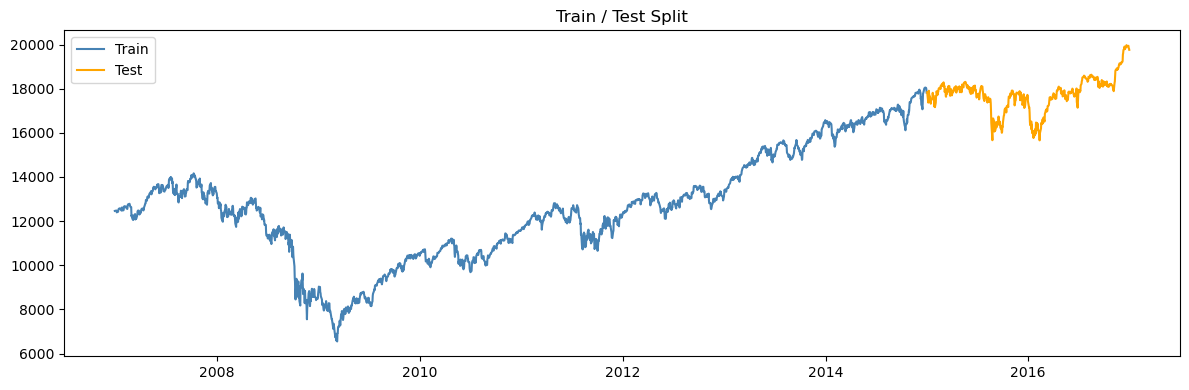

In [8]:
# Show train/test split on chart
plt.figure(figsize=(12, 4))
plt.plot(df['Close'].iloc[:split], label='Train', color='steelblue')
plt.plot(df['Close'].iloc[split:], label='Test',  color='orange')
plt.title('Train / Test Split')
plt.legend()
plt.tight_layout()
plt.show()

## Step 5 — Build LSTM Model

In [9]:
# Build model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(STEPS, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

C:\Users\Tanishka Mishra\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0221 - val_loss: 0.0037
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0037 - val_loss: 0.0013
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0030 - val_loss: 0.0011
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0026 - val_loss: 0.0011
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0024 - val_loss: 9.5472e-04
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0023 - val_loss: 9.7553e-04
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0022 - val_loss: 4.5192e-04
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 9/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0021 - val_loss: 7.3800e-04
Epoch 10/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0020 - val_loss: 5.1903e-04
Epoch 11/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0020 - val_loss: 8.9852e-04
Epoch 12/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 

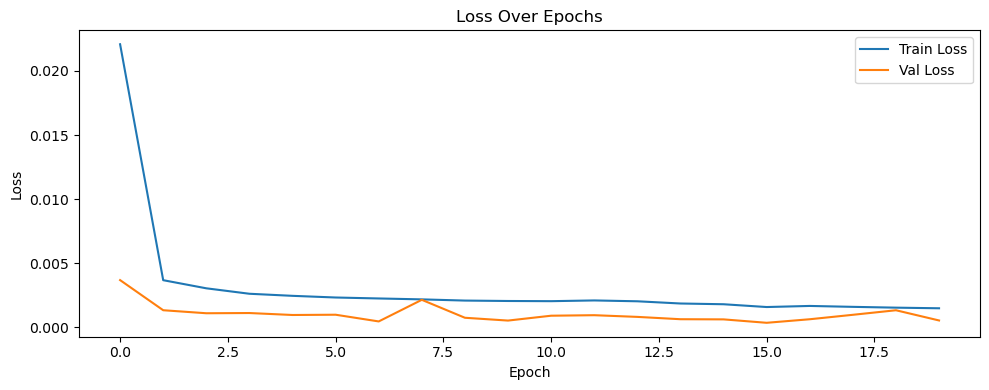

In [11]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Step 6 — Predict & Evaluate

In [12]:
# Make predictions
pred = model.predict(X_test)

# Convert back to original scale
pred_price   = scaler.inverse_transform(pred)
actual_price = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrics
rmse = np.sqrt(mean_squared_error(actual_price, pred_price))
mae  = mean_absolute_error(actual_price, pred_price)
mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100
acc  = 100 - mape

print(f"RMSE     : {rmse:,.2f}")
print(f"MAE      : {mae:,.2f}")
print(f"MAPE     : {mape:.2f}%")
print(f"Accuracy : {acc:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
RMSE     : 359.04
MAE      : 294.13
MAPE     : 1.65%
Accuracy : 98.35%


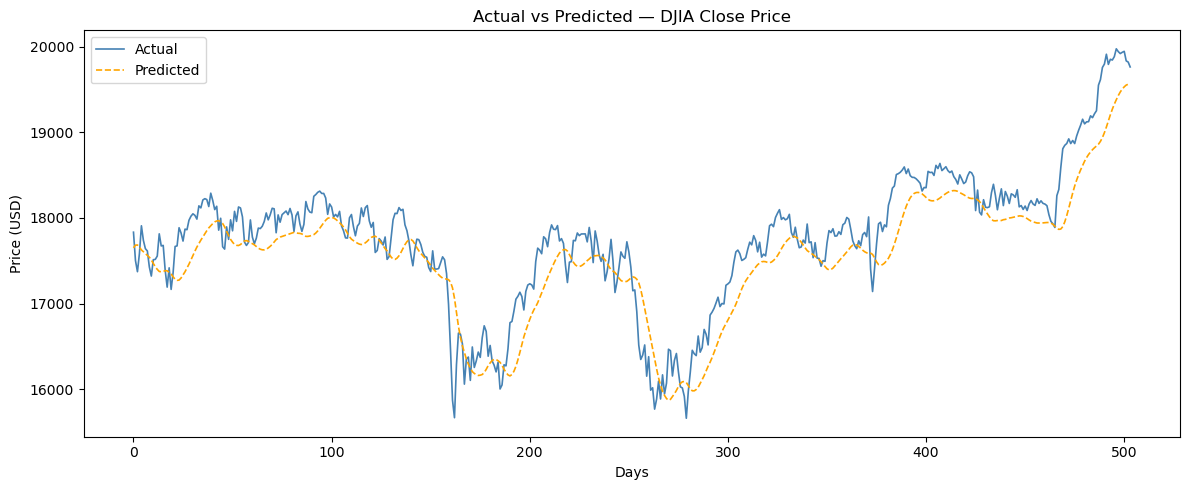

In [13]:
# Plot Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(actual_price, label='Actual',    color='steelblue', linewidth=1.2)
plt.plot(pred_price,   label='Predicted', color='orange',    linewidth=1.2, linestyle='--')
plt.title('Actual vs Predicted — DJIA Close Price')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 7 — Forecast Next 30 Days

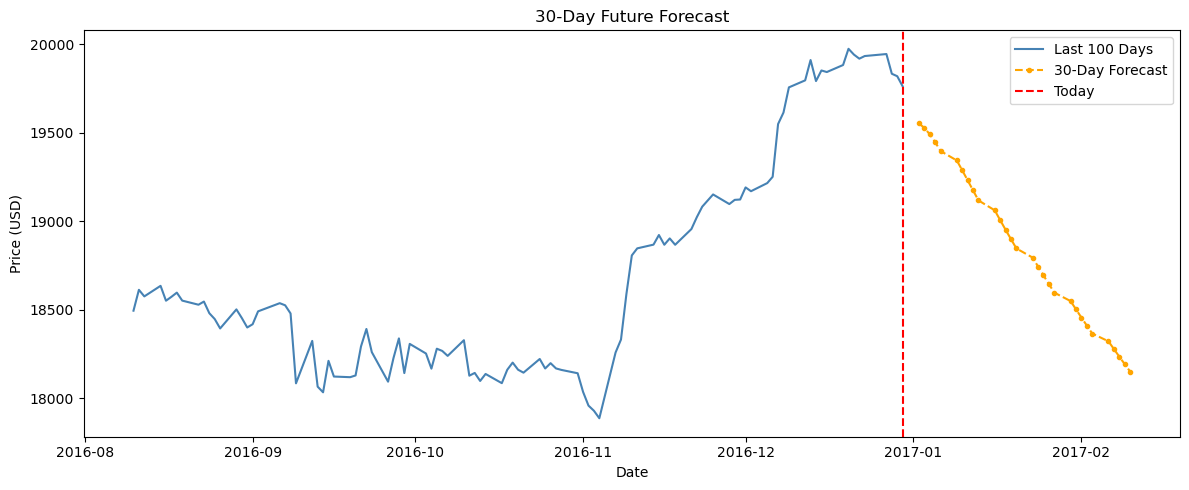

Last Price   : $19,762.60
Day 1 Forecast : $19,553.12
Day 30 Forecast: $18,151.72


In [14]:
# Predict next 30 days
last_seq  = scaled[-STEPS:].copy()
forecast  = []

for _ in range(30):
    inp  = last_seq[-STEPS:].reshape(1, STEPS, 1)
    out  = model.predict(inp, verbose=0)[0, 0]
    forecast.append(out)
    last_seq = np.append(last_seq, [[out]], axis=0)

# Scale back
forecast_prices = scaler.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()

# Future dates
future_dates = pd.bdate_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(df['Close'].iloc[-100:], label='Last 100 Days', color='steelblue')
plt.plot(future_dates, forecast_prices, label='30-Day Forecast', color='orange', linestyle='--', marker='o', markersize=3)
plt.axvline(x=df.index[-1], color='red', linestyle='--', label='Today')
plt.title('30-Day Future Forecast')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Last Price   : ${df['Close'].iloc[-1]:,.2f}")
print(f"Day 1 Forecast : ${forecast_prices[0]:,.2f}")
print(f"Day 30 Forecast: ${forecast_prices[-1]:,.2f}")